<a href="https://colab.research.google.com/github/evelynsaez/analisis_suicidios_antioquia/blob/data_zharita/Proyecto_Evelyn_Isamar_Yurany.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [257]:
import pandas as pd #Se importa libreria de pandas
import numpy as np #Se importa libreria de numpy
import matplotlib.pyplot as plt #Se importa libreria de matplotlib
import seaborn as sns #Se importa libreria de seaborn

#Se importa el archivo desde github
url = ('https://github.com/evelynsaez/analisis_suicidios_antioquia/raw/refs/heads/data_zharita/Cantidad_anual_de_suicidios_reportados_en_el_Departamento_de_Antioquia_desde_2005_20251127.csv')
df = pd.read_csv(url) #Se lee el archivo en formato csv con pandas
#Se reemplaza las comas por espacio y float por int
df['NumeroPoblacionObjetivo'] = df['NumeroPoblacionObjetivo'].str.replace(',', '').astype(float).astype(int)

df.head(5) #Se puede observar los primeros registros de la hoja de calculo


,NombreMunicipio,CodigoMunicipio,Ubicación,NombreRegion,CodigoRegion,Anio,CausaMortalidad,TipoPoblacionObjetivo,NumeroPoblacionObjetivo,NumeroCasos
0,Abejorral,5002,POINT (-75.427045 5.79145),ORIENTE,7,2005,Suicidios,Poblacion total,20249,2
1,Abriaquí,5004,POINT (-76.064563 6.63197),OCCIDENTE,6,2005,Suicidios,Poblacion total,2690,0
2,Alejandría,5021,POINT (-75.141258 6.376923),ORIENTE,7,2005,Suicidios,Poblacion total,3816,0
3,Amagá,5030,POINT (-75.703216 6.04063),SUROESTE,8,2005,Suicidios,Poblacion total,27155,0
4,Amalfi,5031,POINT (-75.075028 6.907385),NORDESTE,4,2005,Suicidios,Poblacion total,20525,2


In [258]:
#Se eliminan las columnas CausaMortalida, CodigoRegion, CodigoMunicipio y TipoPoblacionObjetivo
df_sincolumnas = df.drop(['CausaMortalidad', 'TipoPoblacionObjetivo', 'CodigoRegion', 'CodigoMunicipio'], axis=1)
#Se cambia el nombre de las columnas
df_nuevo_nombre = df_sincolumnas.rename(columns={'NombreMunicipio': 'Municipio', 'NombreRegion': 'Region','NumeroPoblacionObjetivo': 'Poblacion','NumeroCasos': 'Casos'})
df_nuevo_nombre.head(5)

,Municipio,Ubicación,Region,Anio,Poblacion,Casos
0,Abejorral,POINT (-75.427045 5.79145),ORIENTE,2005,20249,2
1,Abriaquí,POINT (-76.064563 6.63197),OCCIDENTE,2005,2690,0
2,Alejandría,POINT (-75.141258 6.376923),ORIENTE,2005,3816,0
3,Amagá,POINT (-75.703216 6.04063),SUROESTE,2005,27155,0
4,Amalfi,POINT (-75.075028 6.907385),NORDESTE,2005,20525,2


In [259]:
df_nuevo_nombre.shape #Se confirman cuantas columnas y filas tiene el dataframe al quitar las columnas no relevantes

(2500, 6)

In [260]:
df_nuevo_nombre.info () #Se observa que no hay datos nulos

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Municipio  2500 non-null   object
 1   Ubicación  2500 non-null   object
 2   Region     2500 non-null   object
 3   Anio       2500 non-null   int64 
 4   Poblacion  2500 non-null   int64 
 5   Casos      2500 non-null   int64 
dtypes: int64(3), object(3)
memory usage: 117.3+ KB


In [261]:
# Calcular estadísticas básicas (media, mediana, desviación estándar)
media = df_nuevo_nombre['Casos'].mean()
mediana = df_nuevo_nombre['Casos'].median()
desviacion_estandar = df_nuevo_nombre['Casos'].std()

print (f'''
El promedio del # de suicidios en Antioquia en los ultimos 20 años es: {media} casos
La mediana del # de suicidios en Antioquia en los ultimos 20 años es de: {mediana} casos
La desviación estandar del # de suicidios en Antioquia en los ultimos 20 años es de: {desviacion_estandar} casos

''')


El promedio del # de suicidios en Antioquia en los ultimos 20 años es: 3.1664 casos
La mediana del # de suicidios en Antioquia en los ultimos 20 años es de: 1.0 casos
La desviación estandar del # de suicidios en Antioquia en los ultimos 20 años es de: 15.003438016032302 casos




In [262]:
#Agrupa los casos por region para mostrar cuantos casos hubo en cada region
df_nuevo_nombre = df_nuevo_nombre[(df_nuevo_nombre['Anio'] >= 2005) & (df_nuevo_nombre['Anio'] <= 2024)]
suma_casos_region = df_nuevo_nombre.groupby('Region')['Casos'].sum().reset_index()

suma_casos_region

,Region,Casos
0,BAJO CAUCA,206
1,MAGDALENA MEDIO,126
2,NORDESTE,267
3,NORTE,372
4,OCCIDENTE,257
5,ORIENTE,948
6,SUROESTE,573
7,URABA,421
8,VALLE DE ABURRA,4746


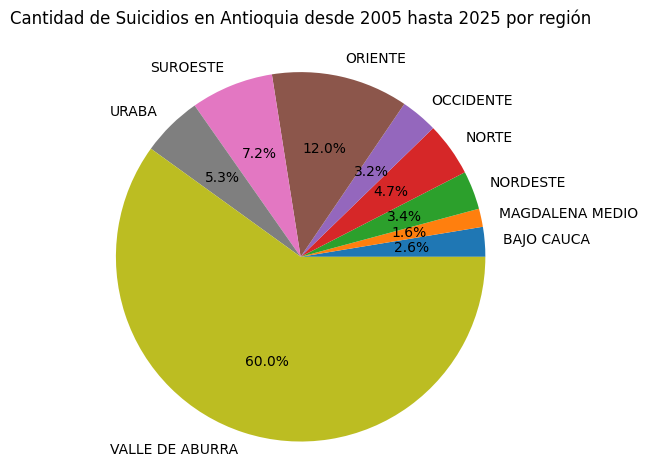

In [263]:
import pandas as pd
import matplotlib.pyplot as plt

plt.pie(suma_casos_region['Casos'], labels=suma_casos_region['Region'], autopct="%0.1f%%") #Se crea una grafica de pastel

plt.axis("equal")
plt.title('Cantidad de Suicidios en Antioquia desde 2005 hasta 2025 por región\n') #Titulo
plt.tight_layout()

plt.show()


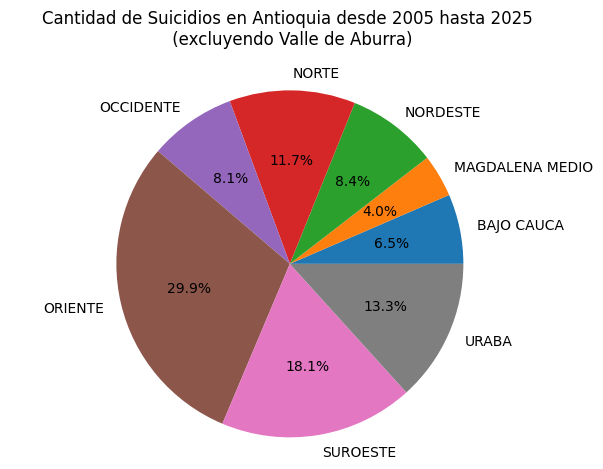

In [264]:
 #Agrupa los casos por region para mostrar cuantos casos hubo en cada region
df_cont = df_cont[(df_cont['Anio'] >= 2005) & (df_cont['Anio'] <= 2024)]
suma_casos_region = df_cont.groupby('Region')['Casos'].sum().reset_index()



umbral = 100
df_altos = suma_casos_region[suma_casos_region['Casos'] > umbral]

plt.pie(df_altos['Casos'], labels=df_altos['Region'], autopct="%0.1f%%") #Se crea una grafica de pastel

plt.axis("equal")
plt.title('Cantidad de Suicidios en Antioquia desde 2005 hasta 2025 \n (excluyendo Valle de Aburra)\n') #Titulo
plt.tight_layout()

plt.show()

In [265]:
suma_columna_casos = df["NumeroCasos"].sum() #Suma los casos de suicidio en 20 años

print (suma_columna_casos)

7916


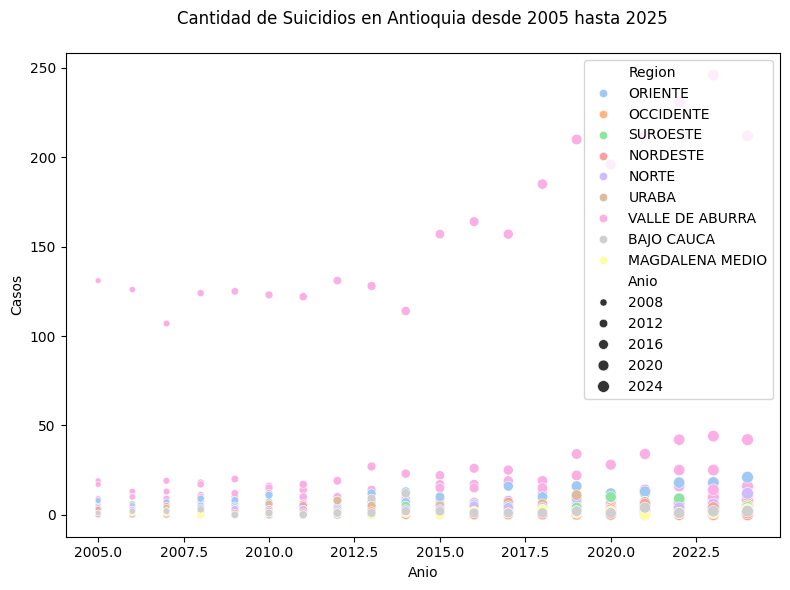

In [266]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Relación entre 'Año' y 'Casos', diferenciando por la región
df_nuevo_nombre = df_nuevo_nombre[(df_nuevo_nombre["Anio"] >= 2005) & (df_nuevo_nombre["Anio"] <= 2024)]
suma_casos_region = df_nuevo_nombre.groupby("Anio")["Casos"].sum().reset_index()

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df_nuevo_nombre,
    x='Anio',
    y='Casos',
    hue='Region',
    size='Anio',
    palette='pastel'

)

plt.title('Cantidad de Suicidios en Antioquia desde 2005 hasta 2025\n')
plt.tight_layout()
#plt.savefig('diagrama.png', dpi=300, transparent=True)
plt.show()

In [267]:
#Excluir el valle de aburra:

excluir = [
    'VALLE DE ABURRA',
]
df_cont = df_nuevo_nombre[~df_nuevo_nombre['Region'].isin(excluir)]

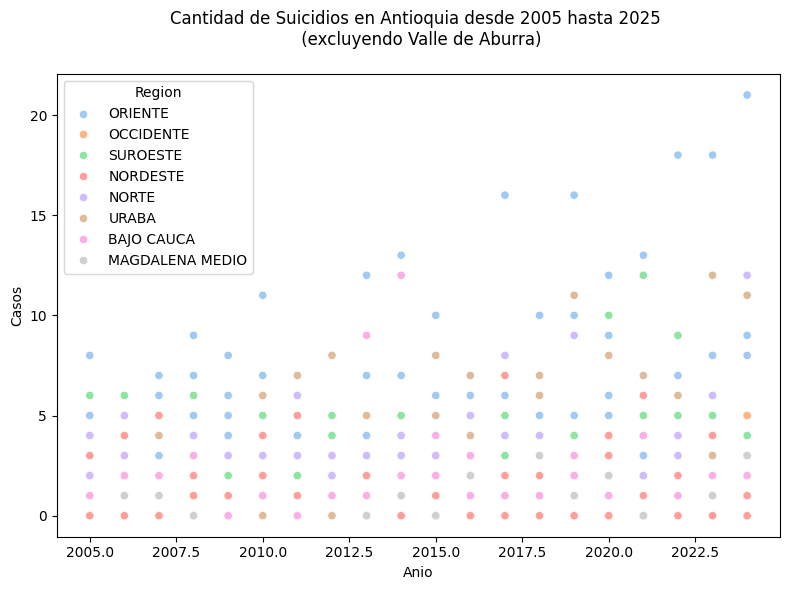

In [268]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df_cont,
    x='Anio',
    y='Casos',
    hue='Region',
    #size='Anio',
    palette='pastel'

)

plt.title('Cantidad de Suicidios en Antioquia desde 2005 hasta 2025 \n (excluyendo Valle de Aburra)\n')
plt.tight_layout()
#plt.savefig('diagrama.png', dpi=300, transparent=True)
plt.show()

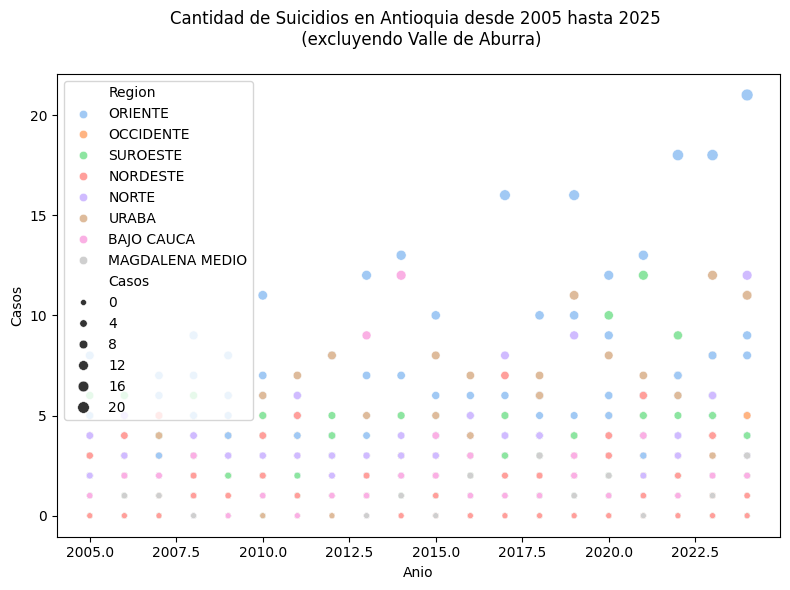

In [269]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df_cont,
    x='Anio',
    y='Casos',
    hue='Region',
    size='Casos',
    palette='pastel'

)

plt.title('Cantidad de Suicidios en Antioquia desde 2005 hasta 2025 \n (excluyendo Valle de Aburra)\n')
plt.tight_layout()
#plt.savefig('diagrama.png', dpi=300, transparent=True)
plt.show()

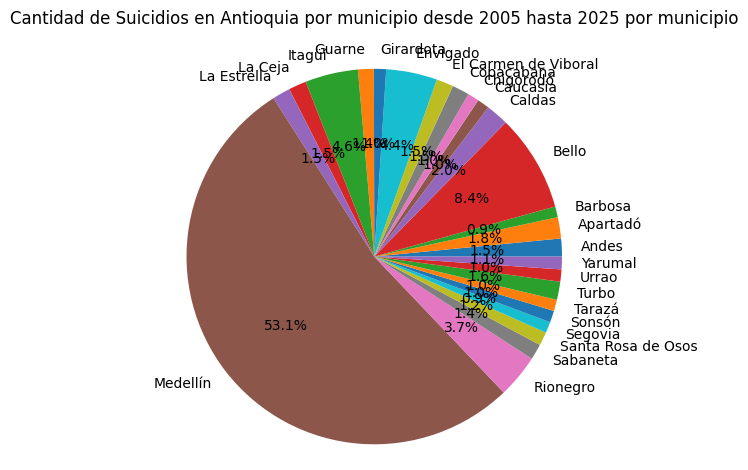

In [273]:
import pandas as pd
import matplotlib.pyplot as plt

#Agrupa los casos por municipio para mostrar cuantos casos hubo en cada municipio en 20 años
df_nuevo_nombre = df_nuevo_nombre[(df_nuevo_nombre['Anio'] >= 2005) & (df_nuevo_nombre['Anio'] <= 2024)]
suma_casos_municipio = df_nuevo_nombre.groupby('Municipio')['Casos'].sum().reset_index()


umbral = 50 #Filtrar por un valor mínimo (ej. mayores a 50 suicidios por municipio)
df_altos = suma_casos_municipio[suma_casos_municipio['Casos'] > umbral]

plt.pie(df_altos['Casos'], labels=df_altos['Municipio'], autopct="%0.1f%%") #Se crea una grafica de pastel

plt.axis("equal")
plt.title('Cantidad de Suicidios en Antioquia por municipio desde 2005 hasta 2025 por municipio\n') #Titulo
plt.tight_layout()

plt.show()



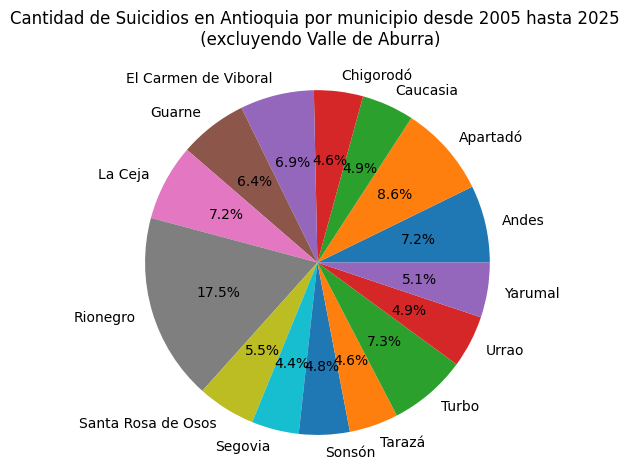

In [280]:
 #Agrupa los casos por region para mostrar cuantos casos hubo en cada region
df_cont = df_cont[(df_cont['Anio'] >= 2005) & (df_cont['Anio'] <= 2024)]
suma_casos_municipio = df_cont.groupby('Municipio')['Casos'].sum().reset_index()



umbral = 50 #Filtrar por un valor mínimo (ej. mayores a 50 suicidios por municipio)
df_altos = suma_casos_municipio[suma_casos_municipio['Casos'] > umbral]

plt.pie(df_altos['Casos'], labels=df_altos['Municipio'], autopct="%0.1f%%") #Se crea una grafica de pastel

plt.axis("equal")
plt.title('Cantidad de Suicidios en Antioquia por municipio desde 2005 hasta 2025 \n (excluyendo Valle de Aburra)\n') #Titulo
plt.tight_layout()

plt.show()